In [4]:
%%capture
### Install SAM from github
!pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-7p4qjcda
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-7p4qjcda
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'segment_anything' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'segment_anything'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36637 sha256=a31d0288a59c705498ebe59

In [1]:
import os
import cv2
import sys
import torch
import monai
import yaml
import numpy
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F


from tqdm import tqdm
import src.utils as utils
from statistics import mean
from torch.optim import Adam
from src.lora import LoRA_sam
from src.dataloader import DatasetSegmentation, collate_fn
from src.processor import Samprocessor
from src.segment_anything import build_sam_vit_b, SamPredictor
from src.lora import LoRA_sam
from scipy.ndimage import label
from src.processor import Samprocessor
from torchvision.utils import save_image
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
from src.dataloader import DatasetSegmentation, collate_fn
from src.segment_anything import build_sam_vit_b, SamPredictor
from torch.optim import Adam 
from torch.nn.functional import threshold, normalize
from segment_anything import sam_model_registry, SamPredictor

 

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sam = sam_model_registry["vit_b"](
    checkpoint="./models/sam/sam_vit_b_01ec64.pth"
)

## change it if you want to run this notebook with cpu
device = "cpu" #cuda
sam.to(device=device)
predictor_sam = SamPredictor(sam)
   
sam.eval()

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )


In [3]:

def load_lora(rank):
    
    sam = sam_model_registry["vit_b"](
        checkpoint="./models/sam/sam_vit_b_01ec64.pth"
    )
    device ="cpu" ## change it 
    sam.to(device=device)

    seg_loss = monai.losses.DiceCELoss(sigmoid=True, squared_pred=True, reduction='mean')
    
    with open("config.yaml", "r") as ymlfile:
       config_file = yaml.load(ymlfile, Loader=yaml.Loader)
    
    sam_lora = LoRA_sam(sam, rank)
    sam_lora.load_lora_parameters(f"./models/lora_weights/lora_rank{rank}.safetensors")  
    samlora = sam_lora.sam
    samlora.to(device)      
    samlora.eval()
    predictor_sam_lora = SamPredictor(samlora)

    return predictor_sam_lora


In [4]:
import h5py 
import numpy 
import matplotlib.pyplot as plt 
import os

filename = "./data/meteor.hdf5"

def plot_data(filename):

    with h5py.File(filename,"r") as f:
 
        utc_time =  f['Data']['utctime'][:]
        empty_snr = numpy.zeros((3,f['Data']['dataPP_SNR']['channel00'][:].shape[0],
                                     f['Data']['dataPP_SNR']['channel00'][:].shape[1]))*0

        empty_snr[0] = 10*numpy.log10(f['Data']['dataPP_SNR']['channel00'][:])
        empty_snr[1] = 10*numpy.log10(f['Data']['dataPP_SNR']['channel01'][:])
        empty_snr[2] = 10*numpy.log10(f['Data']['dataPP_SNR']['channel02'][:])
        
        snr = numpy.max(empty_snr,axis=0)

        #snr[snr<-5] = -5

 
    threshold_1 = numpy.percentile(snr,q=30)
    threshold_2 = numpy.percentile(snr,q=85)

    if threshold_1< -5:
        threshold_1  = -5

    nx,ny = snr.shape
    fig = plt.figure(figsize=(16,9),dpi=100)

    n_bins = snr.shape[1]
    
    heights = numpy.linspace(70,120,n_bins)

    ax = fig.add_axes([0, 0, 1, 1])  

    p20 = numpy.percentile(snr,20)
   
    pc = ax.pcolormesh(
        numpy.arange(snr.shape[0]) ,
        heights,
        snr.T,
        cmap='jet',
        vmin=threshold_1,
        vmax=threshold_2,
        shading="nearest",
    )
 
    fig.tight_layout()
    ax.set_axis_off()
    
    filename = "./figs/meteor.png"

    if not os.path.isdir(os.path.dirname(filename)):
        os.makedirs(os.path.dirname(filename))
        
    
    fig.savefig(filename)

    print("Figure saved in:",filename)
    
    plt.close("all")

    return filename, snr 
    
fig_path,snr = plot_data(filename)

/tmp/ipykernel_1318070/3596770433.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Figure saved in: ./figs/meteor.png


In [5]:
# drawing mask
img_bgr = cv2.imread(fig_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

### true mask
img_bgr_segmented = cv2.imread("./data/mask.png" )
img_rgb_segmented = cv2.cvtColor(img_bgr_segmented, cv2.COLOR_BGR2RGB)
### transformamos a mascara binaria
img_rgb_segmented[(img_rgb_segmented>0)[:,:,0],:] =255
img_rgb_segmented = img_rgb_segmented.astype(numpy.uint8)
img_rgb_segmented = img_rgb_segmented[:,:,0]

In [6]:
import cv2
import matplotlib.pyplot as plt

### sam with lora
model_lora= load_lora(rank=256)
model_lora.set_image(img_rgb)

In [7]:
## obtained from yolo
bbox = np.array([
    460,330,
    1140,545
])
 
# ----------------------------
# SAM inference
# ----------------------------
sam_masks_lora, _, _ = model_lora.predict(
    box=bbox[None, :],
    multimask_output=False
)

pred_mask_lora = sam_masks_lora[0] > 0  # [H, W] bool

predictor_sam.set_image(img_rgb)

sam_masks_base, _, _ = predictor_sam.predict(
    box=bbox[None, :],
    multimask_output=False
)

pred_mask_base = sam_masks_base[0] > 0  # [H, W] bool


In [ ]:
plt.figure(figsize=(9, 3),dpi=120)

pred_mask_base_bool = pred_mask_base.astype(bool)
pred_mask_lora_bool = pred_mask_lora.astype(bool)
img_rgb_segmented_bool = img_rgb_segmented.astype(bool)

intersection_base = np.logical_and(pred_mask_base_bool, img_rgb_segmented_bool ).sum()
intersection_lora = np.logical_and(pred_mask_lora_bool, img_rgb_segmented_bool ).sum()

dice_base= (2.0 * intersection_base) / (
    pred_mask_base_bool.sum() + img_rgb_segmented_bool.sum() + 1e-8
)

dice_lora= (2.0 * intersection_lora) / (
    pred_mask_lora_bool.sum() + img_rgb_segmented_bool.sum() + 1e-8
)

 
plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(img_rgb_segmented, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(pred_mask_base.astype(numpy.uint8), cmap="gray")
plt.title(f"SAM")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(pred_mask_lora.astype(numpy.uint8), cmap="gray")
plt.title(f"SAM + LoRa")
plt.axis("off")
plt.show()

print(f"=> SAM Dice:{dice_base:.3f}")
print(f"=> SAM + LoRa Dice:{dice_lora:.3f}")

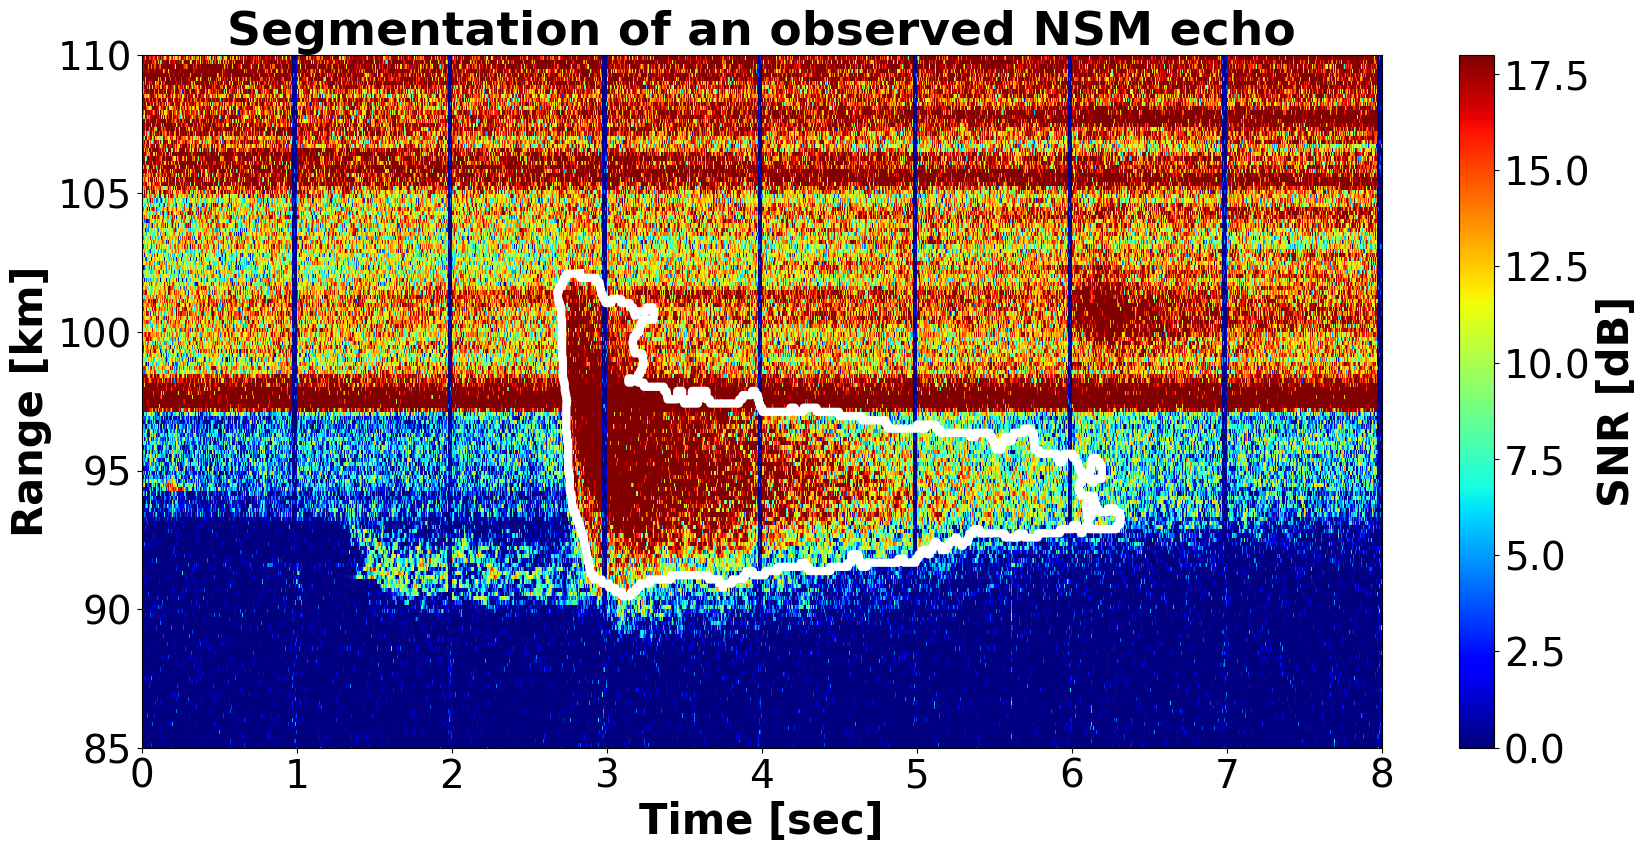

In [26]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from skimage import measure
from dateutil.relativedelta import relativedelta
import numpy as np
from datetime import datetime
 

pred_mask_lora_ = cv2.resize(
    pred_mask_lora.astype(np.uint8),
    (nx, ny),                # (time, height)
    interpolation=cv2.INTER_NEAREST
).astype(bool)
pred_mask_lora_ = pred_mask_lora_[::-1,:]



mask = pred_mask_lora_.astype(bool)

### resolution radar
dt = 2 / 800

nx, ny = snr.shape

time_x = np.arange(nx) * dt
heights = np.linspace(70, 120, ny)

contours = measure.find_contours(mask, level=0.5)

fig = plt.figure(figsize=(20,9), dpi=100)
ax = fig.add_subplot(1,1,1)

pc = ax.pcolormesh(
    time_x,
    heights,
    snr.T,
    cmap='jet',
    vmin=0,
    vmax=18,
    shading='nearest'
)

for contour in contours:


    contour_time = contour[:,1] * dt

    contour_height = np.interp(
        contour[:,0],
        np.arange(ny),
        heights
    )

    ax.plot(
        contour_time,
        contour_height,
        color='white',
        linewidth=6
    )


fontsize = 30
labelsize = 28

title_size=34

ax.set_xlabel("Time [sec]", fontsize=fontsize, fontweight='bold')
ax.set_ylabel("Range [km]", fontsize=fontsize, fontweight='bold')

title = f"Segmentation of an observed NSM echo"

ax.tick_params(labelsize=labelsize)
ax.set_title(title,fontsize=title_size,fontweight='bold' )
ax.set_ylim(85,110)
ax.set_xlim(0,8)

cbar = fig.colorbar(pc, ax=ax)

cbar.set_label(
    "SNR [dB]",
    fontsize=fontsize,
    fontweight='bold'
)

cbar.ax.tick_params(labelsize=labelsize)

fig.savefig(
    f"./figs/figure_4.png",
    transparent=True,
    bbox_inches='tight'
)